# Housing Price Dataset — Exploratory Data Analysis & Preprocessing

This is a **single self-contained notebook**. It has no dependency on `train.py`
or any helper module — everything (config, cleaning, encoding, feature
engineering, plotting helpers) is defined in the setup cell below.

**Contents**
1. Setup & configuration
2. Load the raw data
3. Structure & summary statistics
4. Data-quality audit (missing, duplicates, constants)
5. Preprocessing — cleaning, encoding, feature engineering
6. Univariate analysis — continuous, discrete, categorical
7. Target analysis — `price` distribution, skew, normality
8. Bivariate analysis — numeric vs target, categorical vs target
9. Correlation & pairwise structure
10. Multivariate analysis — interactions & segments
11. Outlier analysis (IQR + z-score)
12. Statistical tests (t-test, ANOVA, chi-square, correlation significance)
13. Feature importance (mutual information + Random Forest)
14. PCA & segment clustering
15. Key findings and export

The last cell writes `data/Housing_processed.csv`, which `train.py` consumes.

## 1. Setup & configuration

Everything the rest of the notebook needs is defined here — no imports from
local modules.

In [1]:
import warnings
from pathlib import Path
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")

# --------------------------------------------------------------------------- #
# Configuration
# --------------------------------------------------------------------------- #

BASE_DIR = Path.cwd().parent if Path.cwd().name == "src" else Path.cwd()


@dataclass
class Config:
    base_dir: Path = BASE_DIR
    target: str = "price"

    # theme
    accent: str = "#4C72B0"
    accent_2: str = "#DD8452"
    palette: str = "viridis"

    # column groups
    continuous_cols: list = field(default_factory=lambda: ["price", "area"])
    discrete_cols: list = field(default_factory=lambda: ["bedrooms", "bathrooms", "stories", "parking"])
    binary_cols: list = field(default_factory=lambda: [
        "mainroad", "guestroom", "basement", "hotwaterheating", "airconditioning", "prefarea",
    ])
    nominal_cols: list = field(default_factory=lambda: ["furnishingstatus"])
    numeric_cols: list = field(default_factory=lambda: [
        "price", "area", "bedrooms", "bathrooms", "stories", "parking",
    ])
    furnishing_order: list = field(default_factory=lambda: ["unfurnished", "semi-furnished", "furnished"])

    @property
    def data_dir(self):
        return self.base_dir / "data"

    @property
    def data_path(self):
        return self.data_dir / "Housing.csv"

    @property
    def out_dir(self):
        return self.base_dir / "outputs"

    @property
    def fig_dir(self):
        return self.out_dir / "figures"

    @property
    def processed_path(self):
        return self.data_dir / "Housing_processed.csv"

    def ensure_dirs(self):
        self.fig_dir.mkdir(parents=True, exist_ok=True)


CONFIG = Config()


# --------------------------------------------------------------------------- #
# Plot helpers
# --------------------------------------------------------------------------- #

def apply_style(cfg=CONFIG):
    """One shared matplotlib / seaborn theme."""
    sns.set_theme(style="whitegrid", palette=cfg.palette)
    plt.rcParams.update({"figure.dpi": 100, "axes.titleweight": "bold", "axes.titlesize": 12})


def save_fig(fig, name, cfg=CONFIG):
    """Save a figure into outputs/figures/ and return its path."""
    cfg.ensure_dirs()
    path = cfg.fig_dir / f"{name}.png"
    fig.savefig(path, bbox_inches="tight", dpi=120)
    return path


def inr(x, pos=None):
    """Compact Indian-currency style formatter (works as a tick formatter too)."""
    try:
        x = float(x)
    except (TypeError, ValueError):
        return x
    if abs(x) >= 1e7:
        return f"{x / 1e7:.2f} Cr"
    if abs(x) >= 1e5:
        return f"{x / 1e5:.1f} L"
    return f"{x:,.0f}"


# --------------------------------------------------------------------------- #
# Data loading & auditing
# --------------------------------------------------------------------------- #

def load_raw(cfg=CONFIG):
    """Load the raw dataset from data/Housing.csv."""
    return pd.read_csv(cfg.data_path)


def audit(df, cfg=CONFIG):
    """Per-column dtype / missing / uniqueness summary."""
    rows = []
    for c in df.columns:
        s = df[c]
        rows.append({
            "column": c,
            "dtype": str(s.dtype),
            "n_missing": int(s.isna().sum()),
            "pct_missing": round(s.isna().mean() * 100, 2),
            "n_unique": int(s.nunique(dropna=False)),
            "example": s.dropna().iloc[0] if s.notna().any() else None,
        })
    return pd.DataFrame(rows).set_index("column")


# --------------------------------------------------------------------------- #
# Preprocessing
# --------------------------------------------------------------------------- #

def clean_data(df, cfg=CONFIG):
    """Drop duplicates and normalise text columns."""
    df = df.drop_duplicates().reset_index(drop=True)
    for c in df.select_dtypes(include="object"):
        df[c] = df[c].str.strip().str.lower()
    return df


def encode(df, cfg=CONFIG):
    """Add numeric `<col>_bin` and `furnishing_code` columns (originals kept)."""
    df = df.copy()
    for c in cfg.binary_cols:
        df[f"{c}_bin"] = df[c].map({"yes": 1, "no": 0}).astype("int64")
    order = {k: i for i, k in enumerate(cfg.furnishing_order)}
    df["furnishing_code"] = df["furnishingstatus"].map(order).astype("int64")
    return df


def engineer_features(df, cfg=CONFIG):
    """Ratio / log / score features used throughout the notebook."""
    df = df.copy()
    beds = df["bedrooms"].replace(0, np.nan)
    df["price_per_sqft"] = df["price"] / df["area"]
    df["area_per_bedroom"] = df["area"] / beds
    df["total_rooms"] = df["bedrooms"] + df["bathrooms"]
    df["bath_per_bed"] = df["bathrooms"] / beds
    df["area_per_room"] = df["area"] / df["total_rooms"].replace(0, np.nan)
    df["amenity_score"] = df[[f"{c}_bin" for c in cfg.binary_cols]].sum(axis=1).astype(int)

    # interaction / location features - these lift model accuracy
    # (log-target ensemble in section 13.1: CV R2 ~0.64 RF -> ~0.68)
    df["area_x_ac"] = df["area"] * df["airconditioning_bin"]
    df["area_x_prefarea"] = df["area"] * df["prefarea_bin"]
    df["luxury_score"] = (df["airconditioning_bin"] + df["prefarea_bin"]
                          + df["furnishing_code"] + df["parking"])

    df["log_price"] = np.log1p(df["price"])
    df["log_area"] = np.log1p(df["area"])
    df["price_segment"] = pd.qcut(df["price"], 4, labels=["budget", "mid", "upper", "premium"])
    return df


def preprocess(raw, cfg=CONFIG):
    """clean -> encode -> engineer, in one call."""
    return engineer_features(encode(clean_data(raw, cfg), cfg), cfg)


# --------------------------------------------------------------------------- #
# Outliers
# --------------------------------------------------------------------------- #

def outlier_table(df, cols):
    """Tukey IQR fences and outlier counts for the given columns."""
    rows = []
    for c in cols:
        s = df[c].dropna()
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n = int(((s < lo) | (s > hi)).sum())
        rows.append({
            "feature": c, "lower_fence": lo, "upper_fence": hi, "iqr": iqr,
            "n_outliers": n,
            "pct_outliers": round(n / len(s) * 100, 2) if len(s) else 0.0,
        })
    return pd.DataFrame(rows).set_index("feature")


apply_style(CONFIG)
CONFIG.ensure_dirs()

print("Data file :", CONFIG.data_path)
print("Figures   :", CONFIG.fig_dir)
print("Target    :", CONFIG.target)

Data file : /Users/mapmac/Desktop/D/FAST/SEM-4-Autumn-2026/MLOPs/Assignments/Assignment-1/MLOPs-Assignment-23L8072/data/Housing.csv
Figures   : /Users/mapmac/Desktop/D/FAST/SEM-4-Autumn-2026/MLOPs/Assignments/Assignment-1/MLOPs-Assignment-23L8072/outputs/figures
Target    : price


## 2. Load the raw data

In [2]:
raw = load_raw(CONFIG)
raw.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


## 3. Structure & summary statistics

In [3]:
print(f"Shape: {raw.shape[0]:,} rows x {raw.shape[1]} columns\n")
print("Column types:")
print(raw.dtypes.to_frame("dtype"))

Shape: 545 rows x 13 columns

Column types:
                   dtype
price              int64
area               int64
bedrooms           int64
bathrooms          int64
stories            int64
mainroad          object
guestroom         object
basement          object
hotwaterheating   object
airconditioning   object
parking            int64
prefarea          object
furnishingstatus  object


In [4]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [5]:
# numeric summary
raw.describe().T.style.background_gradient(cmap="Blues", axis=0)

,count,mean,std,min,25%,50%,75%,max
price,545.000000,4766729.247706,1870439.615657,1750000.000000,3430000.000000,4340000.000000,5740000.000000,13300000.000000
area,545.000000,5150.541284,2170.141023,1650.000000,3600.000000,4600.000000,6360.000000,16200.000000
bedrooms,545.000000,2.965138,0.738064,1.000000,2.000000,3.000000,3.000000,6.000000
bathrooms,545.000000,1.286239,0.502470,1.000000,1.000000,1.000000,2.000000,4.000000
stories,545.000000,1.805505,0.867492,1.000000,1.000000,2.000000,2.000000,4.000000
parking,545.000000,0.693578,0.861586,0.000000,0.000000,0.000000,1.000000,3.000000


In [6]:
# categorical summary
raw.describe(include="object").T

,count,unique,top,freq
mainroad,545,2,yes,468
guestroom,545,2,no,448
basement,545,2,no,354
hotwaterheating,545,2,no,520
airconditioning,545,2,no,373
prefarea,545,2,no,417
furnishingstatus,545,3,semi-furnished,227


## 4. Data-quality audit

Missing values, duplicates, cardinality, skew and constant columns in one table.

In [7]:
quality = audit(raw, CONFIG)
quality

,dtype,n_missing,pct_missing,n_unique,example
column,,,,,
price,int64,0,0.0,219,13300000
area,int64,0,0.0,284,7420
bedrooms,int64,0,0.0,6,4
bathrooms,int64,0,0.0,4,2
stories,int64,0,0.0,4,3
mainroad,object,0,0.0,2,yes
guestroom,object,0,0.0,2,no
basement,object,0,0.0,2,no
hotwaterheating,object,0,0.0,2,no


In [8]:
print("Total missing cells :", int(raw.isna().sum().sum()))
print("Duplicate rows      :", int(raw.duplicated().sum()))
constant = [c for c in raw.columns if raw[c].nunique(dropna=False) <= 1]
print("Constant columns    :", constant or "none")

Total missing cells : 0
Duplicate rows      : 0
Constant columns    : none


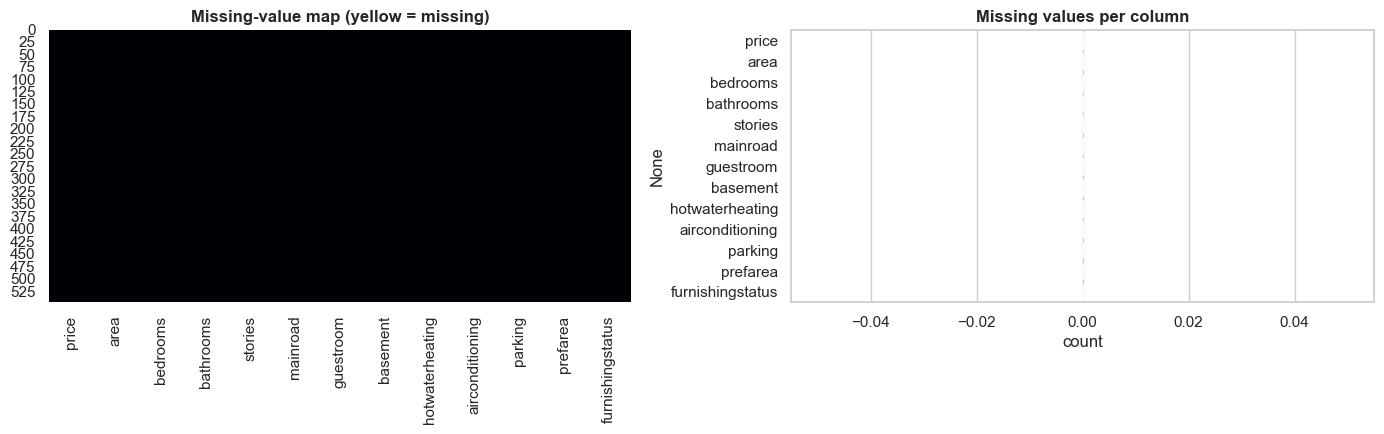

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# missing-value map
sns.heatmap(raw.isna(), cbar=False, cmap="magma", ax=axes[0])
axes[0].set_title("Missing-value map (yellow = missing)")
axes[0].set_xlabel("")

# missing count per column
miss = raw.isna().sum().sort_values(ascending=False)
sns.barplot(x=miss.values, y=miss.index, color=CONFIG.accent, ax=axes[1])
axes[1].set_title("Missing values per column")
axes[1].set_xlabel("count")

plt.tight_layout(); save_fig(fig, "01_missing_values"); plt.show()

## 5. Preprocessing

`preprocess()` in `train.py` chains three steps:

| step | what it does |
|---|---|
| `clean_data`  | trims/lowercases text, coerces numerics, drops duplicates, median/mode imputation |
| `encode`      | `yes/no` -> `*_bin` (1/0), `furnishingstatus` -> ordinal code + one-hot dummies |
| `engineer_features` | `price_per_sqft`, `area_per_bedroom`, `total_rooms`, `bath_per_bed`, `log_price`, `log_area`, `has_parking`, `amenity_score`, `price_segment`, `area_segment` |

In [10]:
df = preprocess(raw, CONFIG)

new_cols = [c for c in df.columns if c not in raw.columns]
print(f"{len(new_cols)} engineered/encoded columns added:\n{new_cols}\n")
df.head()

19 engineered/encoded columns added:
['mainroad_bin', 'guestroom_bin', 'basement_bin', 'hotwaterheating_bin', 'airconditioning_bin', 'prefarea_bin', 'furnishing_code', 'price_per_sqft', 'area_per_bedroom', 'total_rooms', 'bath_per_bed', 'area_per_room', 'amenity_score', 'area_x_ac', 'area_x_prefarea', 'luxury_score', 'log_price', 'log_area', 'price_segment']



,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,...,total_rooms,bath_per_bed,area_per_room,amenity_score,area_x_ac,area_x_prefarea,luxury_score,log_price,log_area,price_segment
0,13300000,7420,4,2,3,yes,no,no,no,yes,...,6,0.500000,1236.666667,3,7420,7420,6,16.403275,8.912069,premium
1,12250000,8960,4,4,4,yes,no,no,no,yes,...,8,1.000000,1120.000000,2,8960,0,6,16.321037,9.100637,premium
2,12250000,9960,3,2,2,yes,no,yes,no,no,...,5,0.666667,1992.000000,3,0,9960,4,16.321037,9.206433,premium
3,12215000,7500,4,2,2,yes,no,yes,no,yes,...,6,0.500000,1250.000000,4,7500,7500,7,16.318175,8.922792,premium
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,...,5,0.250000,1484.000000,4,7420,0,5,16.250001,8.912069,premium


In [11]:
engineered = ["price_per_sqft", "area_per_bedroom", "total_rooms",
              "bath_per_bed", "amenity_score", "log_price", "log_area"]
df[engineered].describe().T

,count,mean,std,min,25%,50%,75%,max
price_per_sqft,545.0,993.326978,346.537025,270.395550,745.370370,952.380952,1184.615385,2640.000000
area_per_bedroom,545.0,1819.852599,839.091825,381.000000,1237.500000,1666.666667,2183.333333,6600.000000
total_rooms,545.0,4.251376,1.036611,2.000000,4.000000,4.000000,5.000000,8.000000
bath_per_bed,545.0,0.446361,0.159492,0.166667,0.333333,0.400000,0.500000,1.000000
amenity_score,545.0,1.983486,1.195004,0.000000,1.000000,2.000000,3.000000,5.000000
log_price,545.0,15.306987,0.372165,14.375127,15.048071,15.283385,15.562970,16.403275
log_area,545.0,8.466765,0.398196,7.409136,8.188967,8.434029,8.757941,9.692828


## 6. Univariate analysis

### 6.1 Continuous features — distribution, KDE and spread

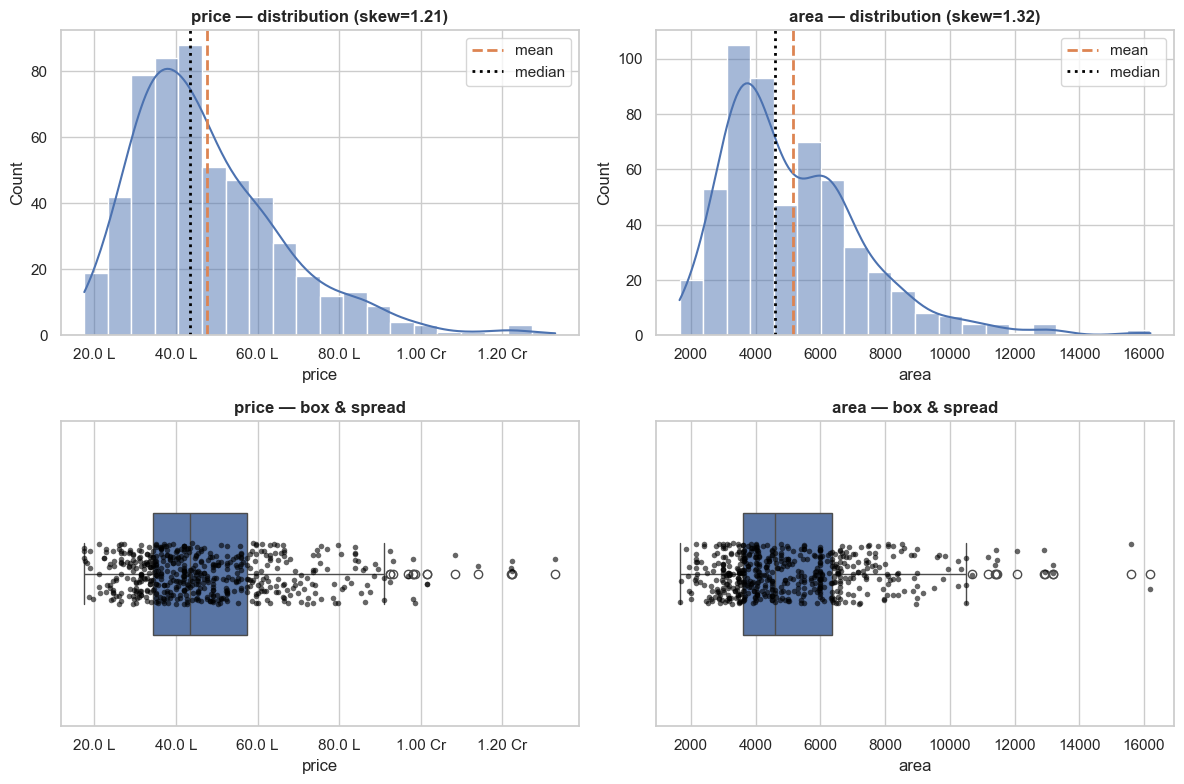

In [12]:
cont = [c for c in CONFIG.continuous_cols if c in df.columns]
fig, axes = plt.subplots(2, len(cont), figsize=(6 * len(cont), 8))
axes = np.atleast_2d(axes)

for j, col in enumerate(cont):
    sns.histplot(df[col], kde=True, bins=min(20, df[col].nunique()),
                 color=CONFIG.accent, ax=axes[0, j])
    axes[0, j].axvline(df[col].mean(), color=CONFIG.accent_2, ls="--", lw=2, label="mean")
    axes[0, j].axvline(df[col].median(), color="black", ls=":", lw=2, label="median")
    axes[0, j].set_title(f"{col} — distribution (skew={df[col].skew():.2f})")
    axes[0, j].legend()

    sns.boxplot(x=df[col], color=CONFIG.accent, ax=axes[1, j], width=0.4)
    sns.stripplot(x=df[col], color="black", size=4, alpha=0.6, ax=axes[1, j])
    axes[1, j].set_title(f"{col} — box & spread")

    if col == "price":
        for ax in (axes[0, j], axes[1, j]):
            ax.xaxis.set_major_formatter(mticker.FuncFormatter(inr))

plt.tight_layout(); save_fig(fig, "02_univariate_continuous"); plt.show()

### 6.2 Discrete numeric features — counts

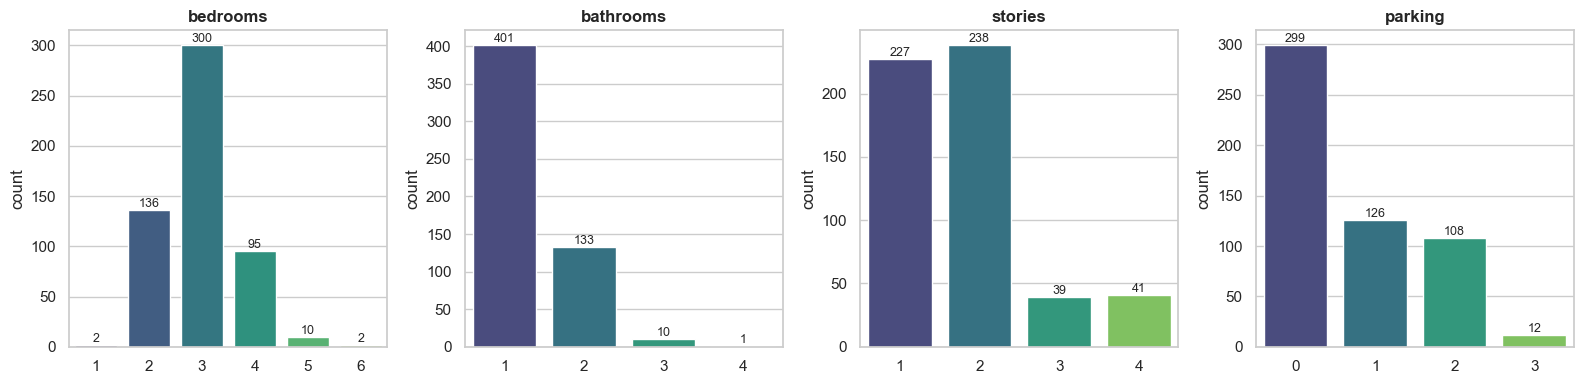

In [13]:
disc = [c for c in CONFIG.discrete_cols if c in df.columns]
fig, axes = plt.subplots(1, len(disc), figsize=(4 * len(disc), 4))
axes = np.ravel(axes)

for ax, col in zip(axes, disc):
    order = sorted(df[col].dropna().unique())
    sns.countplot(x=col, data=df, order=order, palette=CONFIG.palette, ax=ax)
    for p in ax.patches:
        ax.annotate(int(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha="center", va="bottom", fontsize=9)
    ax.set_title(col); ax.set_xlabel("")

plt.tight_layout(); save_fig(fig, "03_univariate_discrete"); plt.show()

### 6.3 Categorical features — amenity flags & furnishing

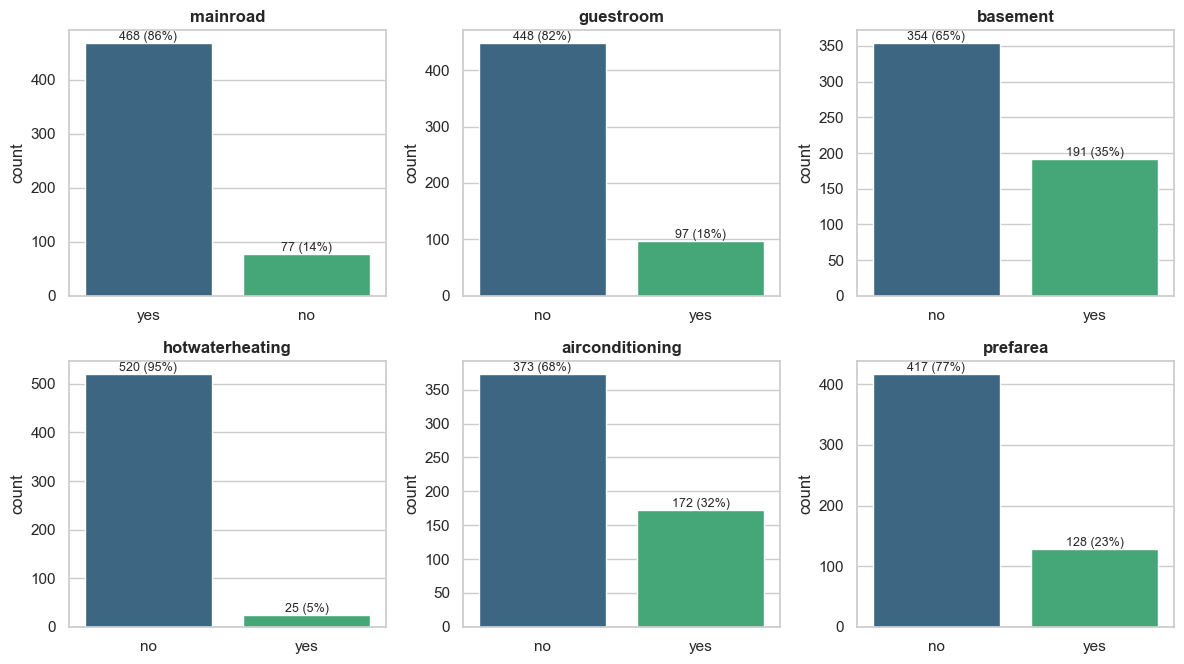

In [14]:
cats = [c for c in CONFIG.binary_cols if c in df.columns]
ncol = 3
nrow = int(np.ceil(len(cats) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4 * ncol, 3.4 * nrow))
axes = np.ravel(axes)

for ax, col in zip(axes, cats):
    counts = df[col].value_counts()
    sns.barplot(x=counts.index, y=counts.values, palette=CONFIG.palette, ax=ax)
    for i, v in enumerate(counts.values):
        ax.text(i, v, f"{v} ({v / len(df) * 100:.0f}%)", ha="center", va="bottom", fontsize=9)
    ax.set_title(col); ax.set_ylabel("count"); ax.set_xlabel("")

for ax in axes[len(cats):]:
    ax.axis("off")

plt.tight_layout(); save_fig(fig, "04_univariate_binary"); plt.show()

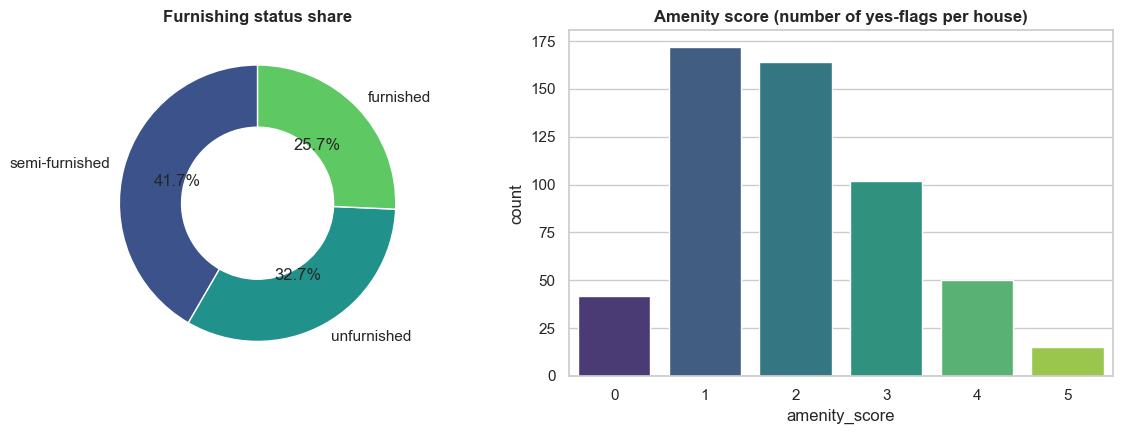

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

fs = df["furnishingstatus"].value_counts()
axes[0].pie(fs.values, labels=fs.index, autopct="%1.1f%%", startangle=90,
            colors=sns.color_palette(CONFIG.palette, len(fs)),
            wedgeprops=dict(width=0.45, edgecolor="white"))
axes[0].set_title("Furnishing status share")

sns.countplot(x="amenity_score", data=df, palette=CONFIG.palette, ax=axes[1])
axes[1].set_title("Amenity score (number of yes-flags per house)")

plt.tight_layout(); save_fig(fig, "05_furnishing_amenities"); plt.show()

## 7. Target analysis — `price`

In [16]:
p = df["price"]
summary = pd.Series({
    "count": p.count(), "mean": p.mean(), "median": p.median(), "std": p.std(),
    "min": p.min(), "25%": p.quantile(.25), "75%": p.quantile(.75), "max": p.max(),
    "IQR": p.quantile(.75) - p.quantile(.25),
    "skewness": p.skew(), "kurtosis": p.kurtosis(),
    "CV_%": p.std() / p.mean() * 100,
}).to_frame("price")
summary

,price
count,5.450000e+02
mean,4.766729e+06
median,4.340000e+06
std,1.870440e+06
min,1.750000e+06
25%,3.430000e+06
75%,5.740000e+06
max,1.330000e+07
IQR,2.310000e+06
skewness,1.212239e+00


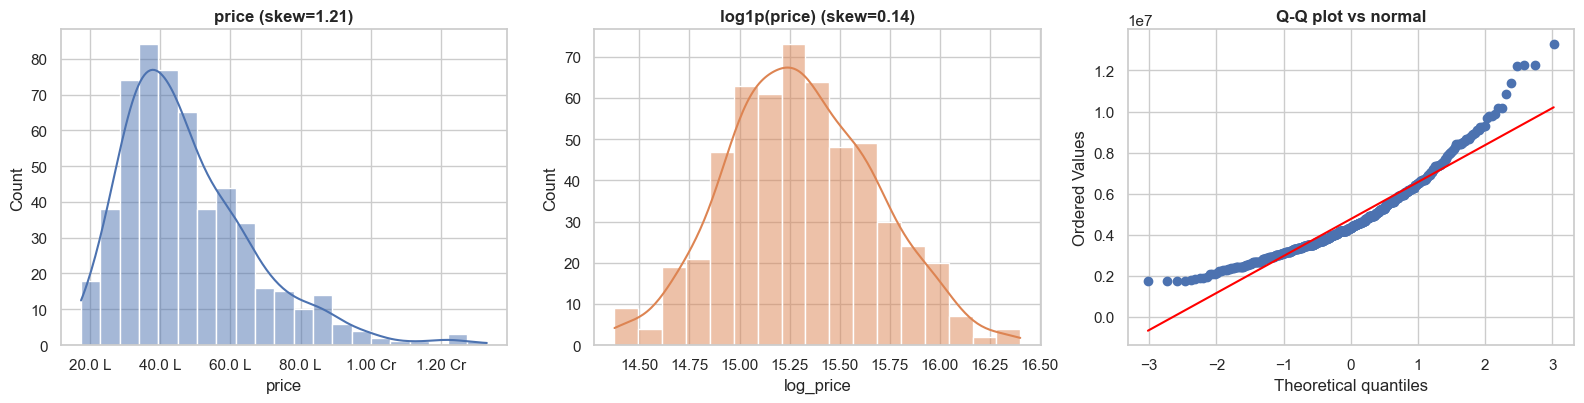

Shapiro-Wilk normality: W=0.9216, p=0.0000 -> not normal (alpha=0.05)


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

sns.histplot(p, kde=True, color=CONFIG.accent, ax=axes[0])
axes[0].set_title(f"price (skew={p.skew():.2f})")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(inr))

sns.histplot(df["log_price"], kde=True, color=CONFIG.accent_2, ax=axes[1])
axes[1].set_title(f"log1p(price) (skew={df['log_price'].skew():.2f})")

stats.probplot(p, dist="norm", plot=axes[2])
axes[2].set_title("Q-Q plot vs normal")
axes[2].get_lines()[0].set_color(CONFIG.accent)

plt.tight_layout(); save_fig(fig, "06_target_distribution"); plt.show()

if len(p) >= 3:
    stat, pv = stats.shapiro(p)
    print(f"Shapiro-Wilk normality: W={stat:.4f}, p={pv:.4f} -> "
          f"{'not normal' if pv < 0.05 else 'cannot reject normality'} (alpha=0.05)")

## 8. Bivariate analysis

### 8.1 Numeric features vs price

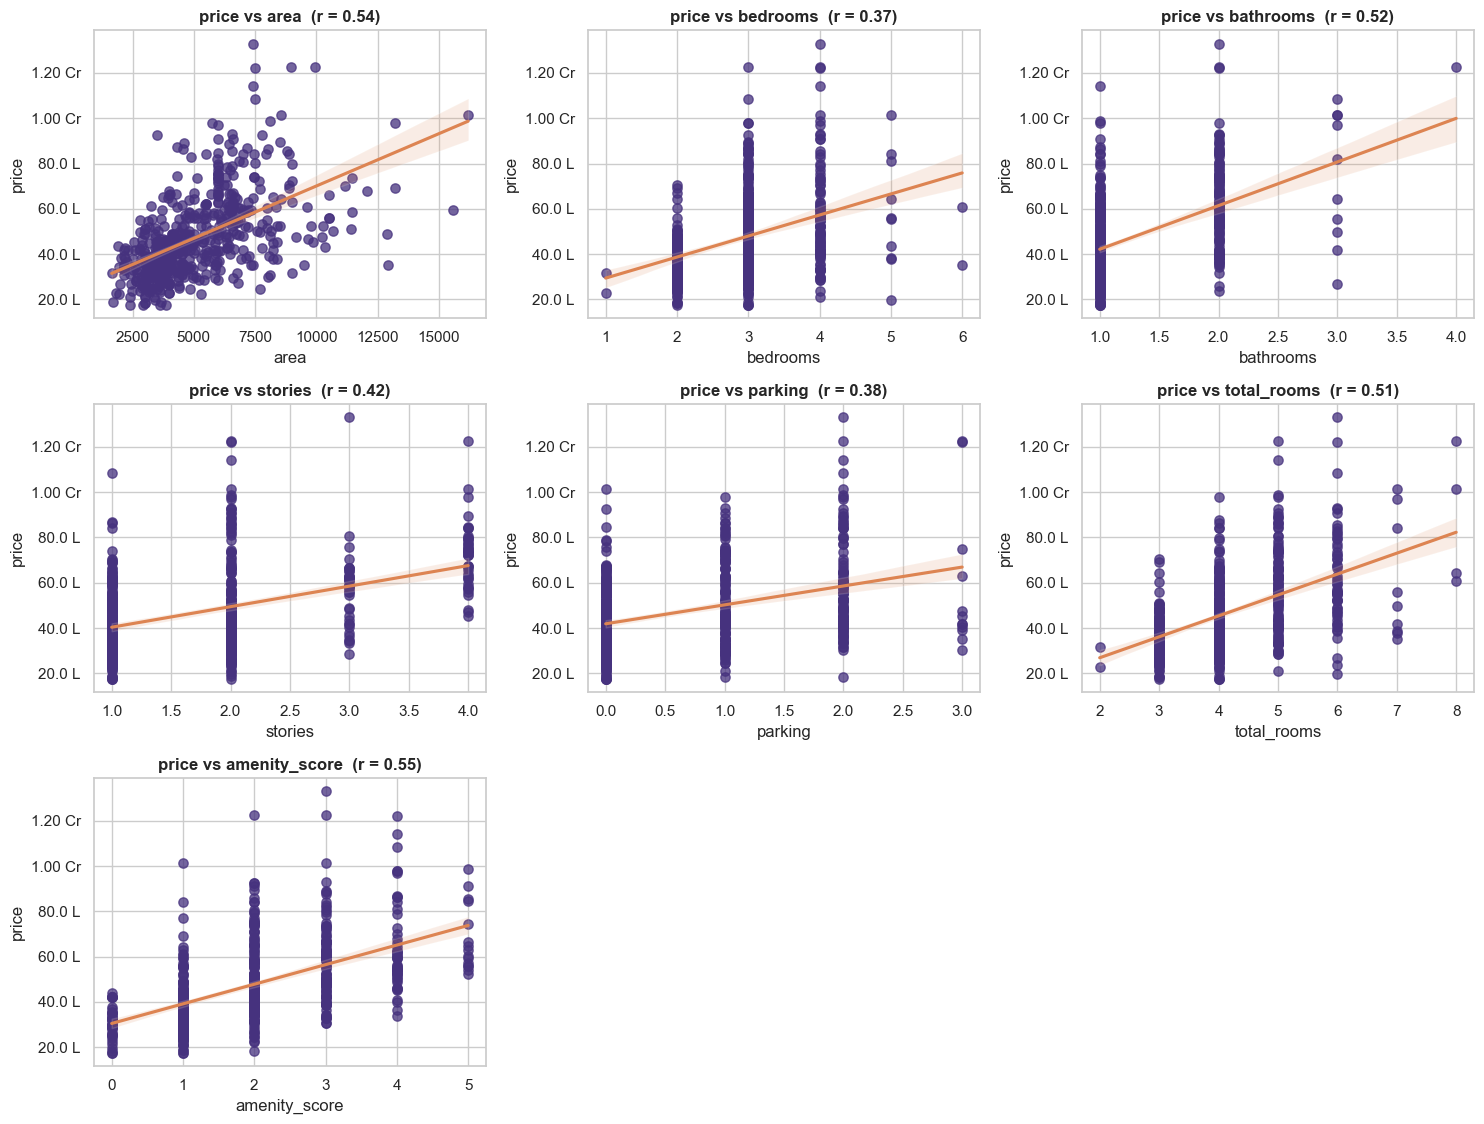

In [18]:
num_feats = [c for c in ["area", "bedrooms", "bathrooms", "stories", "parking",
                         "total_rooms", "amenity_score"] if c in df.columns]
ncol = 3
nrow = int(np.ceil(len(num_feats) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(5 * ncol, 3.8 * nrow))
axes = np.ravel(axes)

for ax, col in zip(axes, num_feats):
    sns.regplot(x=col, y="price", data=df, ax=ax, scatter_kws=dict(s=45, alpha=0.75),
                line_kws=dict(color=CONFIG.accent_2))
    r = df[[col, "price"]].corr().iloc[0, 1]
    ax.set_title(f"price vs {col}  (r = {r:.2f})")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(inr))

for ax in axes[len(num_feats):]:
    ax.axis("off")

plt.tight_layout(); save_fig(fig, "07_bivariate_numeric"); plt.show()

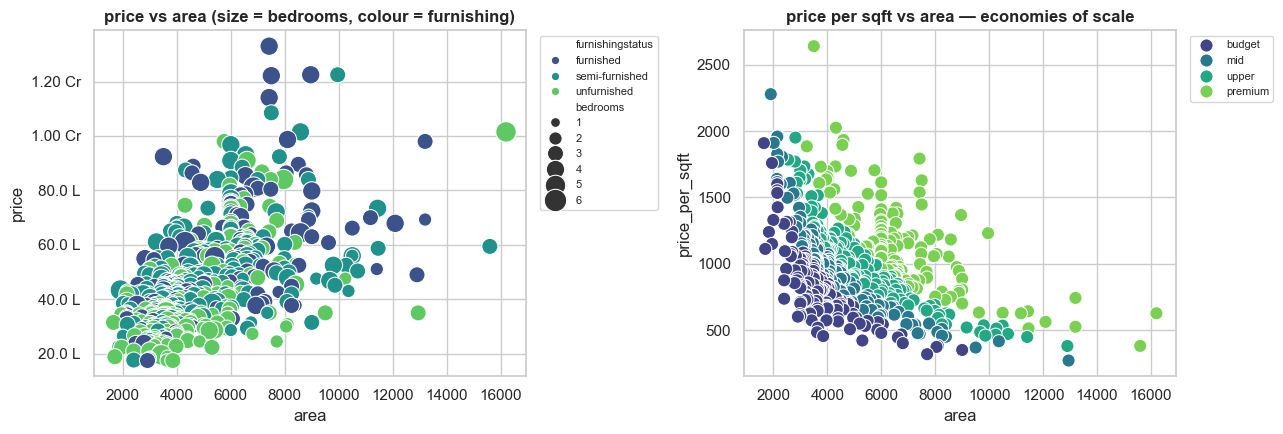

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.scatterplot(x="area", y="price", size="bedrooms", hue="furnishingstatus",
                sizes=(50, 260), data=df, palette=CONFIG.palette, ax=axes[0])
axes[0].set_title("price vs area (size = bedrooms, colour = furnishing)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(inr))
axes[0].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)

sns.scatterplot(x="area", y="price_per_sqft", hue="price_segment",
                data=df, palette=CONFIG.palette, s=90, ax=axes[1])
axes[1].set_title("price per sqft vs area — economies of scale")
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)

plt.tight_layout(); save_fig(fig, "08_area_price_relationship"); plt.show()

### 8.2 Categorical features vs price

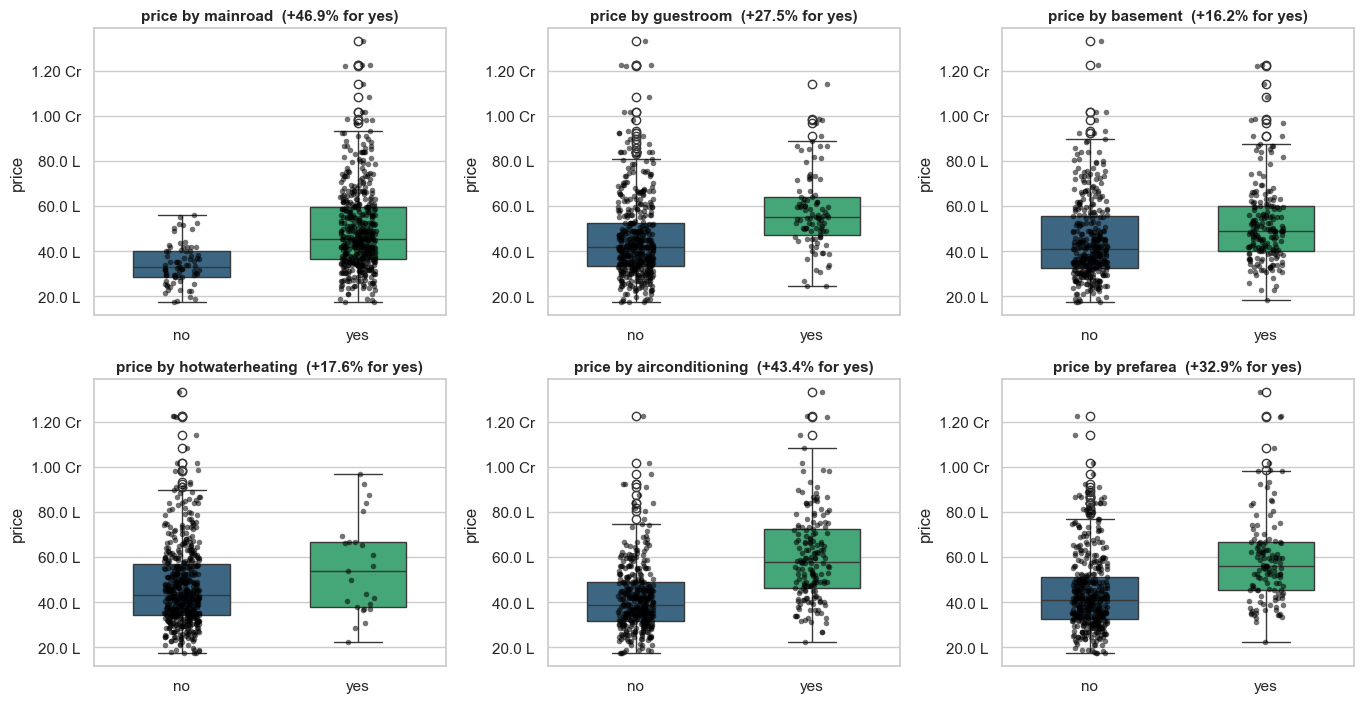

In [20]:
cats = [c for c in CONFIG.binary_cols if c in df.columns]
ncol = 3
nrow = int(np.ceil(len(cats) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4.6 * ncol, 3.6 * nrow))
axes = np.ravel(axes)

for ax, col in zip(axes, cats):
    order = [v for v in ["no", "yes"] if v in set(df[col])]
    sns.boxplot(x=col, y="price", data=df, order=order, palette=CONFIG.palette, ax=ax, width=0.55)
    sns.stripplot(x=col, y="price", data=df, order=order, color="black", size=4, alpha=0.55, ax=ax)
    means = df.groupby(col)["price"].mean()
    delta = ""
    if {"yes", "no"} <= set(means.index):
        delta = f"  ({(means['yes'] / means['no'] - 1) * 100:+.1f}% for yes)"
    ax.set_title(f"price by {col}{delta}", fontsize=11)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(inr))
    ax.set_xlabel("")

for ax in axes[len(cats):]:
    ax.axis("off")

plt.tight_layout(); save_fig(fig, "09_price_by_category"); plt.show()

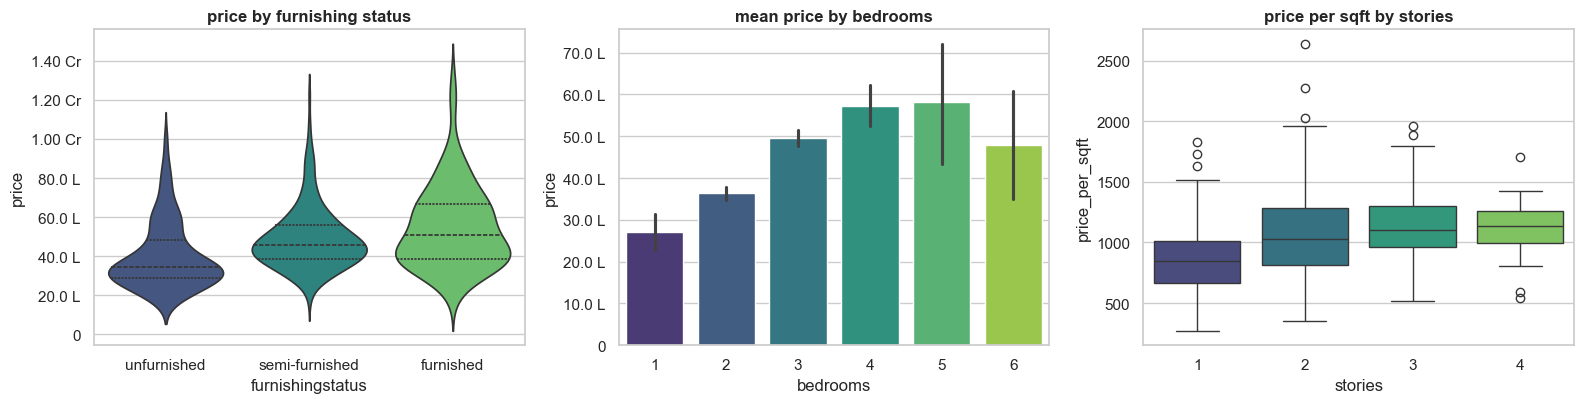

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

sns.violinplot(x="furnishingstatus", y="price", data=df, palette=CONFIG.palette,
               inner="quartile", ax=axes[0],
               order=[k for k in CONFIG.furnishing_order if k in set(df["furnishingstatus"])])
axes[0].set_title("price by furnishing status")

sns.barplot(x="bedrooms", y="price", data=df, palette=CONFIG.palette,
            estimator=np.mean, errorbar=("ci", 95), ax=axes[1])
axes[1].set_title("mean price by bedrooms")

sns.boxplot(x="stories", y="price_per_sqft", data=df, palette=CONFIG.palette, ax=axes[2])
axes[2].set_title("price per sqft by stories")

for ax in axes[:2]:
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(inr))

plt.tight_layout(); save_fig(fig, "10_price_by_group"); plt.show()

In [22]:
# tabular version of the same comparison
rows = []
for col in CONFIG.binary_cols + CONFIG.nominal_cols:
    if col not in df.columns:
        continue
    g = df.groupby(col)["price"].agg(["count", "mean", "median", "std"])
    g.index = pd.MultiIndex.from_product([[col], g.index], names=["feature", "value"])
    rows.append(g)

group_stats = pd.concat(rows)
group_stats.style.background_gradient(cmap="Greens", subset=["mean", "median"])

## 9. Correlation & pairwise structure

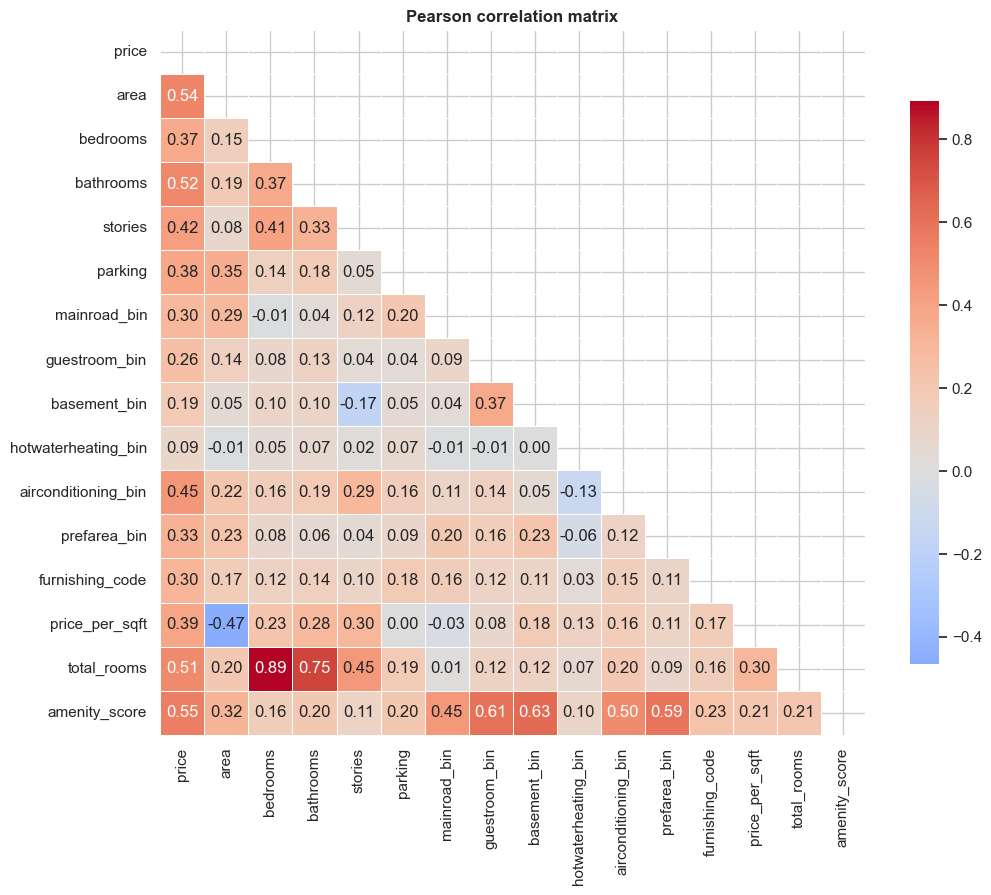

In [23]:
corr_cols = [c for c in CONFIG.numeric_cols
             + [b + "_bin" for b in CONFIG.binary_cols]
             + ["furnishing_code", "price_per_sqft", "total_rooms", "amenity_score"]
             if c in df.columns]
corr = df[corr_cols].astype(float).corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .8}, ax=ax)
ax.set_title("Pearson correlation matrix")
plt.tight_layout(); save_fig(fig, "11_correlation_heatmap"); plt.show()

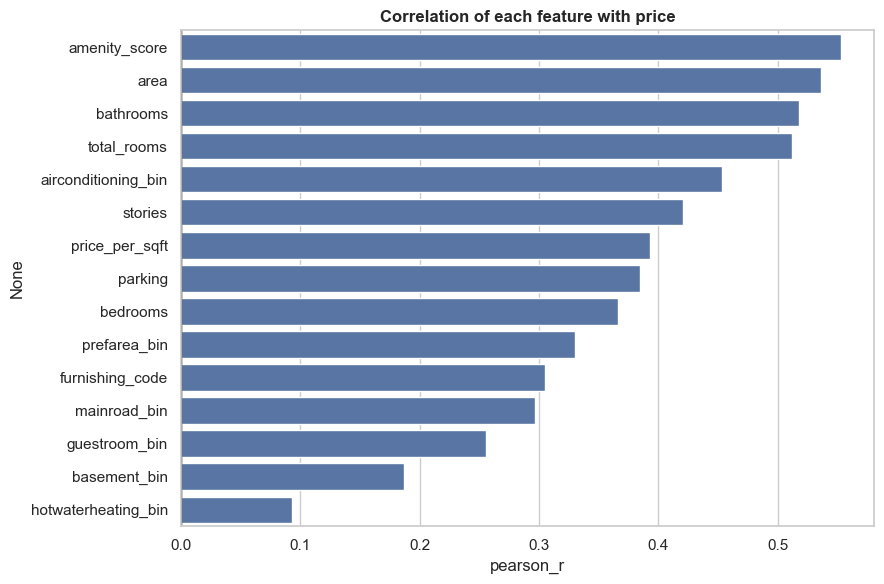

,pearson_r,spearman_r
amenity_score,0.552954,0.615750
area,0.535997,0.602859
bathrooms,0.517545,0.479912
total_rooms,0.511809,0.506768
airconditioning_bin,0.452954,0.457100
stories,0.420712,0.362856
price_per_sqft,0.392921,0.389030
parking,0.384394,0.365372
bedrooms,0.366494,0.390454
prefarea_bin,0.329777,0.347720


In [24]:
target_corr = (corr["price"].drop("price")
               .sort_values(key=abs, ascending=False).to_frame("pearson_r"))
target_corr["spearman_r"] = [
    stats.spearmanr(df[c].astype(float), df["price"]).statistic for c in target_corr.index
]

fig, ax = plt.subplots(figsize=(9, 6))
colors = [CONFIG.accent if v > 0 else CONFIG.accent_2 for v in target_corr["pearson_r"]]
sns.barplot(x=target_corr["pearson_r"], y=target_corr.index, palette=colors, ax=ax)
ax.axvline(0, color="black", lw=1)
ax.set_title("Correlation of each feature with price")
plt.tight_layout(); save_fig(fig, "12_target_correlation"); plt.show()

target_corr

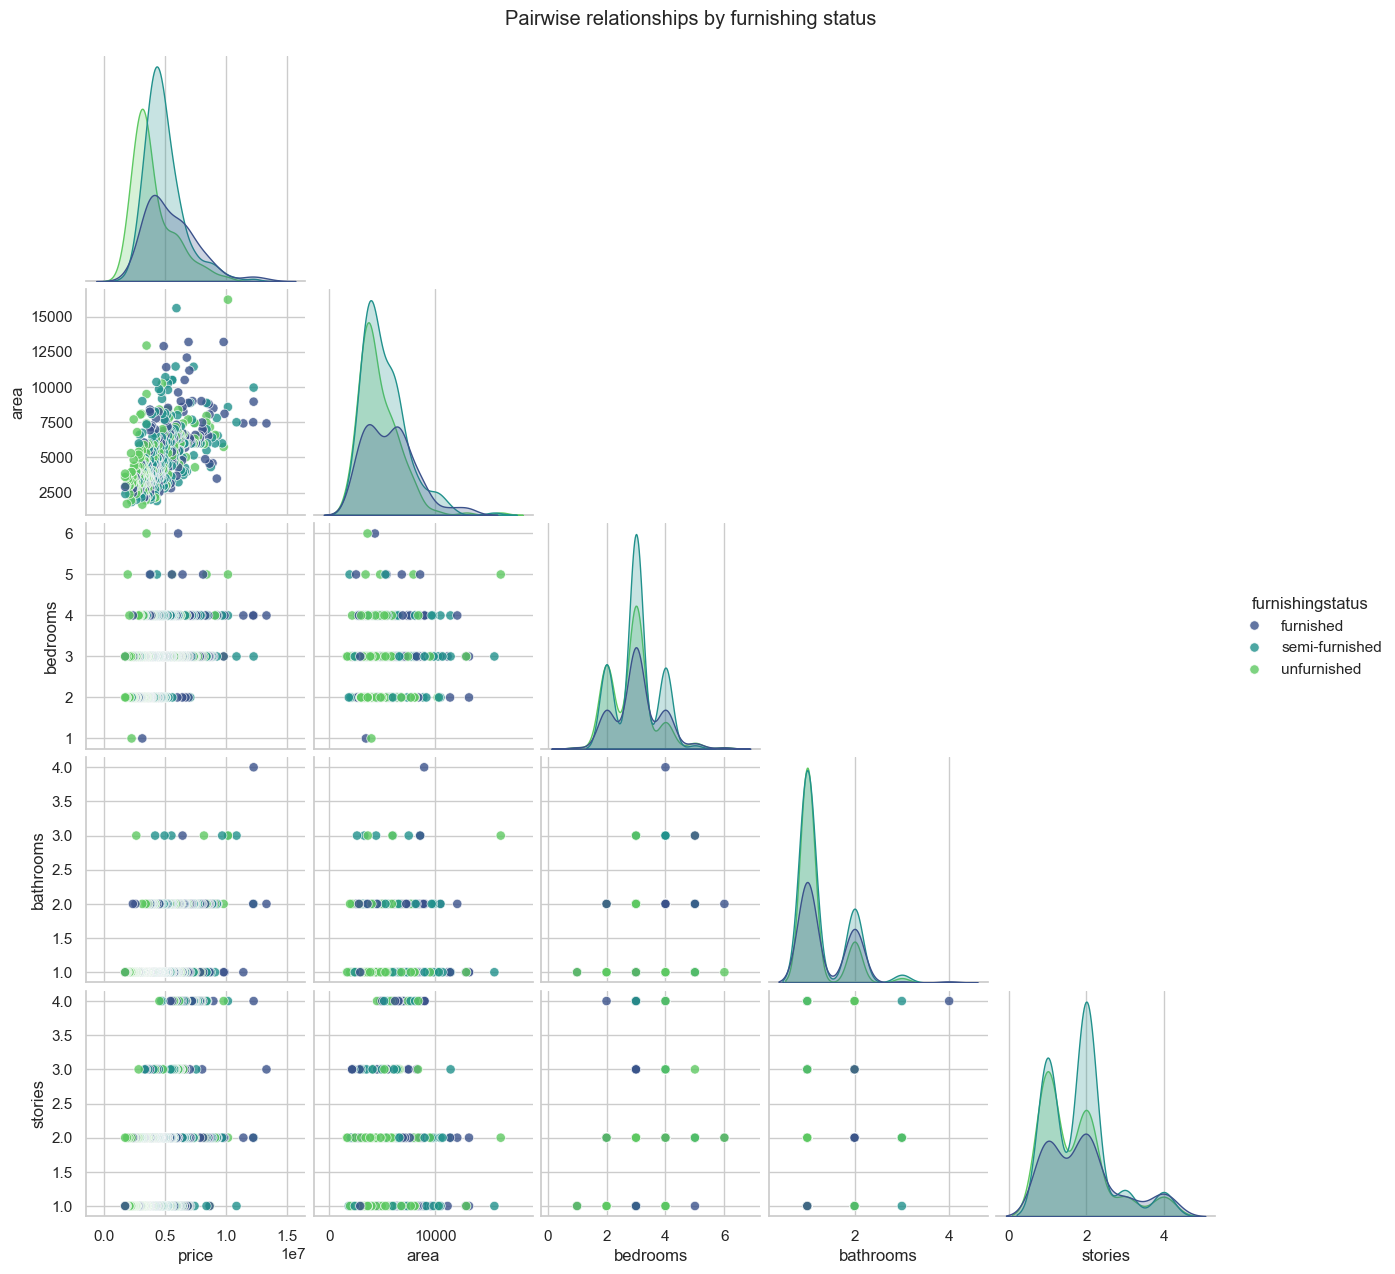

In [25]:
pair_cols = [c for c in ["price", "area", "bedrooms", "bathrooms", "stories"] if c in df.columns]
g = sns.pairplot(df[pair_cols + ["furnishingstatus"]], hue="furnishingstatus",
                 corner=True, diag_kind="kde", palette=CONFIG.palette,
                 plot_kws=dict(s=45, alpha=0.8))
g.figure.suptitle("Pairwise relationships by furnishing status", y=1.02)
save_fig(g.figure, "13_pairplot"); plt.show()

## 10. Multivariate analysis — interactions & segments

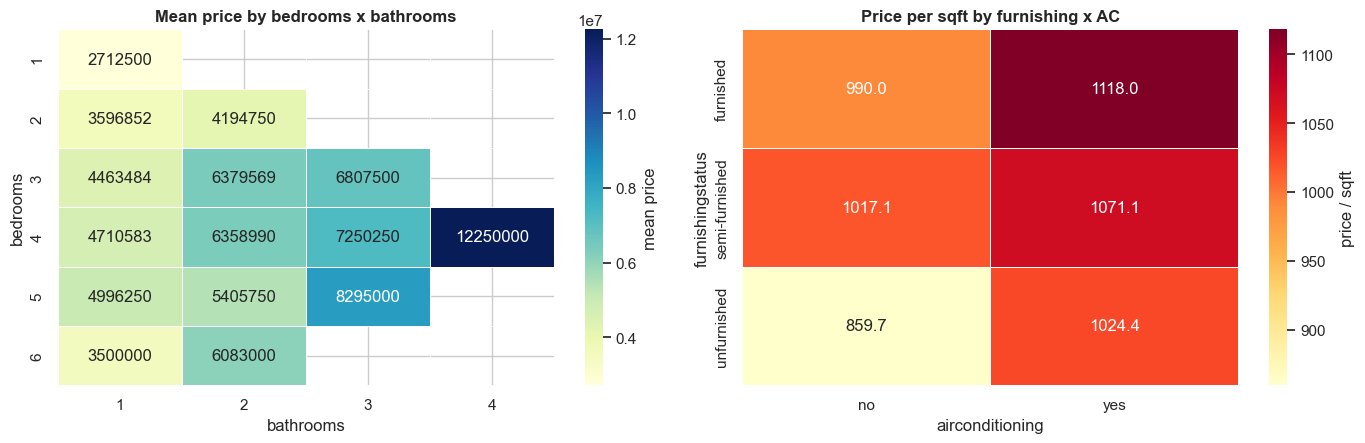

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))

pivot = df.pivot_table(index="bedrooms", columns="bathrooms", values="price", aggfunc="mean")
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlGnBu", linewidths=.5, ax=axes[0],
            cbar_kws={"label": "mean price"})
axes[0].set_title("Mean price by bedrooms x bathrooms")

pivot2 = df.pivot_table(index="furnishingstatus", columns="airconditioning",
                        values="price_per_sqft", aggfunc="mean")
sns.heatmap(pivot2, annot=True, fmt=".1f", cmap="YlOrRd", linewidths=.5, ax=axes[1],
            cbar_kws={"label": "price / sqft"})
axes[1].set_title("Price per sqft by furnishing x AC")

plt.tight_layout(); save_fig(fig, "14_pivot_heatmaps"); plt.show()

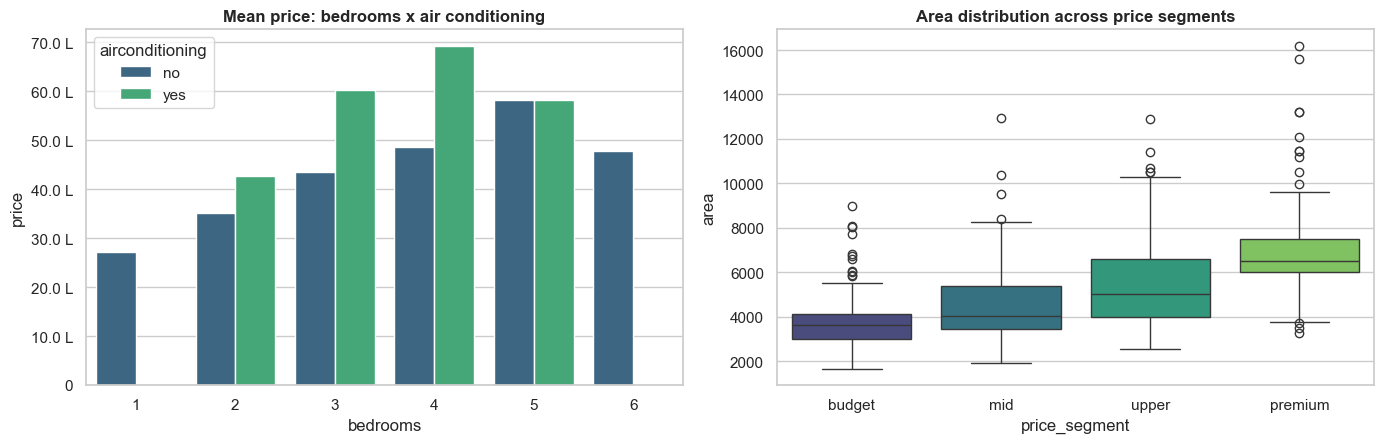

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))

sns.barplot(x="bedrooms", y="price", hue="airconditioning", data=df,
            palette=CONFIG.palette, estimator=np.mean, errorbar=None, ax=axes[0])
axes[0].set_title("Mean price: bedrooms x air conditioning")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(inr))

sns.boxplot(x="price_segment", y="area", data=df, palette=CONFIG.palette, ax=axes[1])
axes[1].set_title("Area distribution across price segments")

plt.tight_layout(); save_fig(fig, "15_interactions"); plt.show()

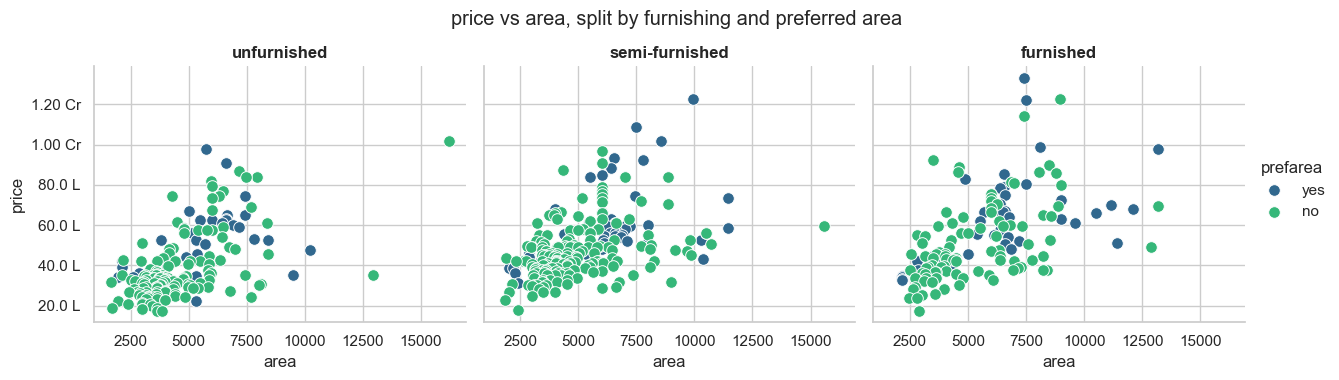

In [28]:
g = sns.FacetGrid(df, col="furnishingstatus", hue="prefarea",
                  height=3.6, aspect=1.15, palette=CONFIG.palette,
                  col_order=[k for k in CONFIG.furnishing_order if k in set(df["furnishingstatus"])])
g.map_dataframe(sns.scatterplot, x="area", y="price", s=70)
g.add_legend(title="prefarea")
g.set_titles("{col_name}")
for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(inr))
g.figure.suptitle("price vs area, split by furnishing and preferred area", y=1.05)
save_fig(g.figure, "16_facet_grid"); plt.show()

In [29]:
# segment profile table
profile = (df.groupby("price_segment")
             .agg(n=("price", "size"),
                  avg_price=("price", "mean"),
                  avg_area=("area", "mean"),
                  avg_ppsf=("price_per_sqft", "mean"),
                  avg_bedrooms=("bedrooms", "mean"),
                  avg_amenities=("amenity_score", "mean"),
                  pct_ac=("airconditioning_bin", "mean"),
                  pct_prefarea=("prefarea_bin", "mean")))
profile[["pct_ac", "pct_prefarea"]] *= 100
profile.style.background_gradient(cmap="Purples")

,n,avg_price,avg_area,avg_ppsf,avg_bedrooms,avg_amenities,pct_ac,pct_prefarea
price_segment,,,,,,,,
budget,137,2853317.518248,3767.715328,826.736104,2.635036,1.080292,8.759124,5.109489
mid,138,3894206.521739,4473.065217,986.858493,2.847826,1.594203,18.115942,15.217391
upper,134,4982250.000000,5550.022388,1008.311714,3.074627,2.402985,36.567164,30.597015
premium,136,7367212.794118,6837.367647,1152.942024,3.308824,2.875000,63.235294,43.382353


## 11. Outlier analysis (Tukey IQR + z-score)

In [30]:
out_cols = [c for c in ["price", "area", "price_per_sqft", "area_per_bedroom"] if c in df.columns]
ot = outlier_table(df, out_cols)
ot

,lower_fence,upper_fence,iqr,n_outliers,pct_outliers
feature,,,,,
price,-35000.000000,9.205000e+06,2.310000e+06,15,2.75
area,-540.000000,1.050000e+04,2.760000e+03,12,2.20
price_per_sqft,86.502849,1.843483e+03,4.392450e+02,11,2.02
area_per_bedroom,-181.250000,3.602083e+03,9.458333e+02,20,3.67


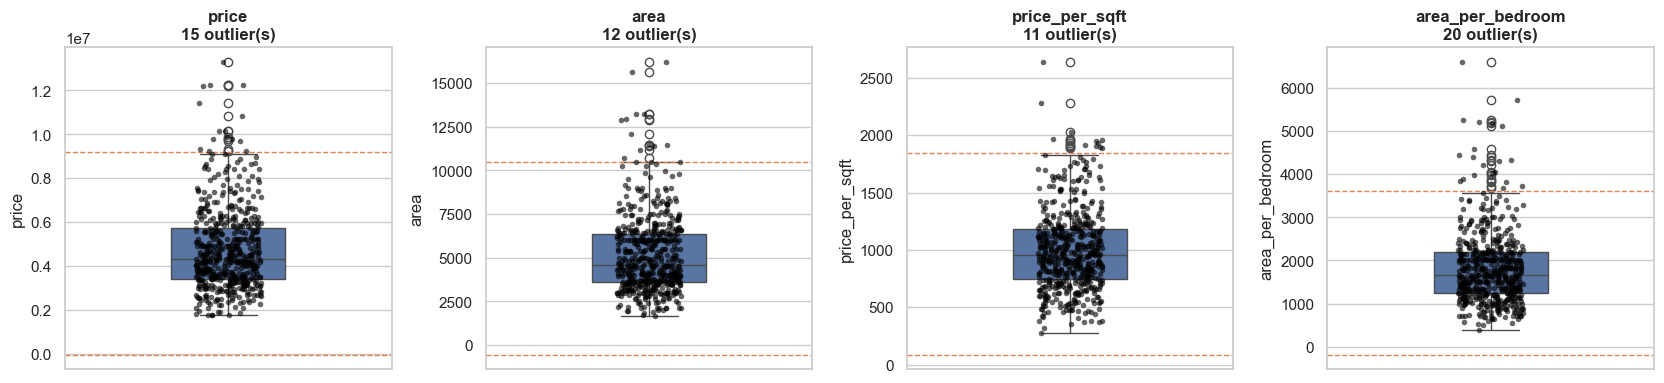

In [31]:
fig, axes = plt.subplots(1, len(out_cols), figsize=(4.2 * len(out_cols), 4))
axes = np.ravel(axes)

for ax, col in zip(axes, out_cols):
    sns.boxplot(y=df[col], color=CONFIG.accent, width=0.35, ax=ax)
    sns.stripplot(y=df[col], color="black", size=4, alpha=0.6, ax=ax)
    lo, hi = ot.loc[col, "lower_fence"], ot.loc[col, "upper_fence"]
    ax.axhline(hi, ls="--", color=CONFIG.accent_2, lw=1)
    ax.axhline(lo, ls="--", color=CONFIG.accent_2, lw=1)
    ax.set_title(f"{col}\n{int(ot.loc[col, 'n_outliers'])} outlier(s)")

plt.tight_layout(); save_fig(fig, "17_outliers"); plt.show()

In [32]:
z = df[out_cols].apply(lambda s: np.abs(stats.zscore(s, nan_policy="omit")))
flagged = df.loc[(z > 3).any(axis=1), ["price", "area", "bedrooms", "price_per_sqft"]]
print(f"Rows with |z| > 3 on any key column: {len(flagged)}")
flagged

Rows with |z| > 3 on any key column: 21


,price,area,bedrooms,price_per_sqft
0,13300000,7420,4,1792.452830
1,12250000,8960,4,1367.187500
2,12250000,9960,3,1229.919679
3,12215000,7500,4,1628.666667
4,11410000,7420,4,1537.735849
5,10850000,7500,3,1446.666667
7,10150000,16200,5,626.543210
10,9800000,13200,3,742.424242
13,9240000,3500,4,2640.000000
61,7070000,8880,2,796.171171


## 12. Statistical tests

Does each feature *significantly* move the price?

In [33]:
results = []
for col in CONFIG.binary_cols:
    if col not in df.columns:
        continue
    a = df.loc[df[col] == "yes", "price"]
    b = df.loc[df[col] == "no", "price"]
    if len(a) < 2 or len(b) < 2:
        results.append({"feature": col, "test": "t-test", "statistic": np.nan,
                        "p_value": np.nan, "significant": "insufficient data"})
        continue
    t, pv = stats.ttest_ind(a, b, equal_var=False)
    pooled = np.sqrt((a.var(ddof=1) + b.var(ddof=1)) / 2)
    d = (a.mean() - b.mean()) / pooled if pooled else np.nan
    results.append({"feature": col, "test": "Welch t-test", "statistic": round(t, 3),
                    "p_value": round(pv, 4), "cohens_d": round(d, 3),
                    "significant": "yes" if pv < 0.05 else "no"})

groups = [g["price"].values for _, g in df.groupby("furnishingstatus") if len(g) >= 2]
if len(groups) >= 2:
    f, pv = stats.f_oneway(*groups)
    results.append({"feature": "furnishingstatus", "test": "ANOVA", "statistic": round(f, 3),
                    "p_value": round(pv, 4), "significant": "yes" if pv < 0.05 else "no"})

pd.DataFrame(results).set_index("feature")

,test,statistic,p_value,cohens_d,significant
feature,,,,,
mainroad,Welch t-test,11.853,0.0000,1.076,yes
guestroom,Welch t-test,6.385,0.0000,0.702,yes
basement,Welch t-test,4.441,0.0000,0.399,yes
hotwaterheating,Welch t-test,1.920,0.0661,0.417,no
airconditioning,Welch t-test,10.659,0.0000,1.032,yes
prefarea,Welch t-test,7.492,0.0000,0.788,yes
furnishingstatus,ANOVA,28.272,0.0000,NaN,yes


In [34]:
# correlation significance for numeric features
rows = []
for col in [c for c in CONFIG.numeric_cols if c != "price"]:
    r, pv = stats.pearsonr(df[col].astype(float), df["price"])
    rho, pv2 = stats.spearmanr(df[col].astype(float), df["price"])
    rows.append({"feature": col, "pearson_r": round(r, 3), "p_value": round(pv, 4),
                 "spearman_rho": round(rho, 3), "spearman_p": round(pv2, 4),
                 "significant": "yes" if pv < 0.05 else "no"})
pd.DataFrame(rows).set_index("feature")

,pearson_r,p_value,spearman_rho,spearman_p,significant
feature,,,,,
area,0.536,0.0,0.603,0.0,yes
bedrooms,0.366,0.0,0.390,0.0,yes
bathrooms,0.518,0.0,0.480,0.0,yes
stories,0.421,0.0,0.363,0.0,yes
parking,0.384,0.0,0.365,0.0,yes


In [35]:
# association between categorical features themselves (chi-square)
cat_all = [c for c in CONFIG.binary_cols + CONFIG.nominal_cols if c in df.columns]
rows = []
for i, a in enumerate(cat_all):
    for b in cat_all[i + 1:]:
        table = pd.crosstab(df[a], df[b])
        if table.shape[0] < 2 or table.shape[1] < 2:
            continue
        try:
            chi2, pv, dof, _ = stats.chi2_contingency(table)
            n = table.values.sum()
            cramers_v = np.sqrt(chi2 / (n * (min(table.shape) - 1)))
            rows.append({"feature_a": a, "feature_b": b, "chi2": round(chi2, 3),
                         "p_value": round(pv, 4), "cramers_v": round(cramers_v, 3)})
        except ValueError:
            continue

chi_df = pd.DataFrame(rows)
chi_df.sort_values("cramers_v", ascending=False).head(15) if len(chi_df) else "no valid pairs"

,feature_a,feature_b,chi2,p_value,cramers_v
6,guestroom,basement,73.421,0.0000,0.367
13,basement,prefarea,27.235,0.0000,0.224
4,mainroad,prefarea,20.440,0.0000,0.194
19,airconditioning,furnishingstatus,14.645,0.0007,0.164
5,mainroad,furnishingstatus,13.387,0.0012,0.157
9,guestroom,prefarea,13.134,0.0003,0.155
8,guestroom,airconditioning,9.643,0.0019,0.133
15,hotwaterheating,airconditioning,7.925,0.0049,0.121
14,basement,furnishingstatus,7.885,0.0194,0.120
10,guestroom,furnishingstatus,7.637,0.0220,0.118


## 13. Feature importance (model-based sanity check)

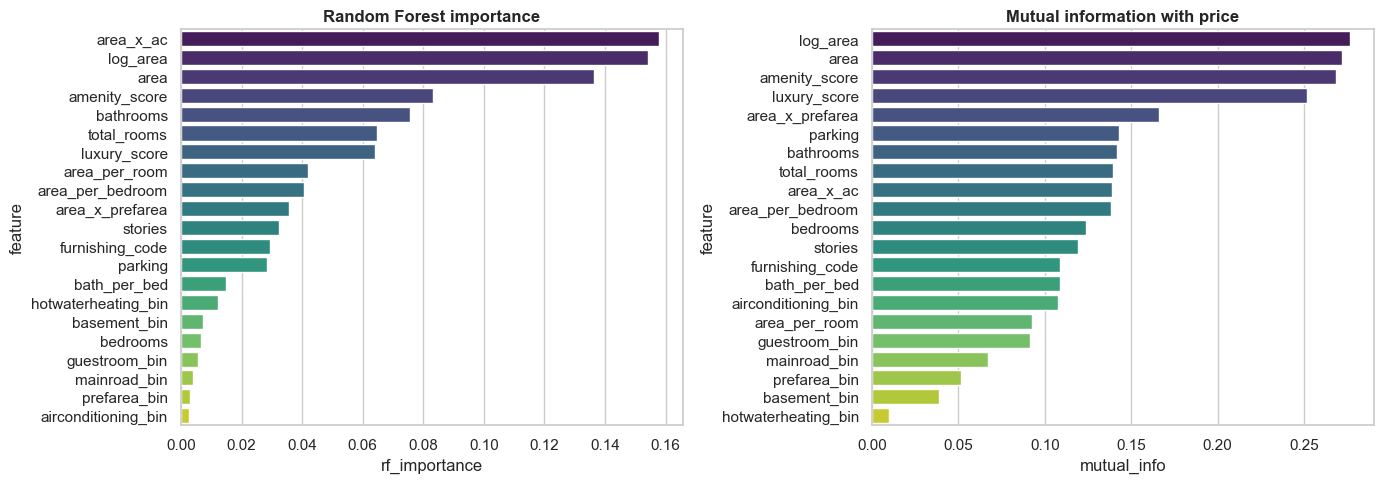

,mutual_info,rf_importance
feature,,
area_x_ac,0.138750,0.157867
log_area,0.276709,0.154196
area,0.272129,0.136406
amenity_score,0.268385,0.083157
bathrooms,0.141937,0.075451
total_rooms,0.139352,0.064729
luxury_score,0.251737,0.064181
area_per_room,0.092342,0.041772
area_per_bedroom,0.138235,0.040453


In [36]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import mutual_info_regression

feat_cols = [c for c in ["area", "bedrooms", "bathrooms", "stories", "parking",
                         "furnishing_code", "amenity_score", "total_rooms",
                         "bath_per_bed", "area_per_room", "area_per_bedroom",
                         "luxury_score", "area_x_ac", "area_x_prefarea", "log_area"]
             + [b + "_bin" for b in CONFIG.binary_cols] if c in df.columns]

X = df[feat_cols].astype(float).fillna(0)
y = df["price"].astype(float)

mi = mutual_info_regression(X, y, random_state=42)
rf = RandomForestRegressor(n_estimators=400, random_state=42, min_samples_leaf=1).fit(X, y)

imp = (pd.DataFrame({"feature": feat_cols,
                     "mutual_info": mi,
                     "rf_importance": rf.feature_importances_})
       .set_index("feature").sort_values("rf_importance", ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=imp["rf_importance"], y=imp.index, palette=CONFIG.palette, ax=axes[0])
axes[0].set_title("Random Forest importance")
sns.barplot(x=imp.sort_values("mutual_info", ascending=False)["mutual_info"],
            y=imp.sort_values("mutual_info", ascending=False).index,
            palette=CONFIG.palette, ax=axes[1])
axes[1].set_title("Mutual information with price")
plt.tight_layout(); save_fig(fig, "18_feature_importance"); plt.show()

imp

## 13.1 Model bake-off — what actually predicts price best

`price` is right-skewed, so we compare models on the raw target vs a `log1p` target, scored with repeated 5-fold cross-validation (honest, low variance). The winner here is what `src/train.py` trains.

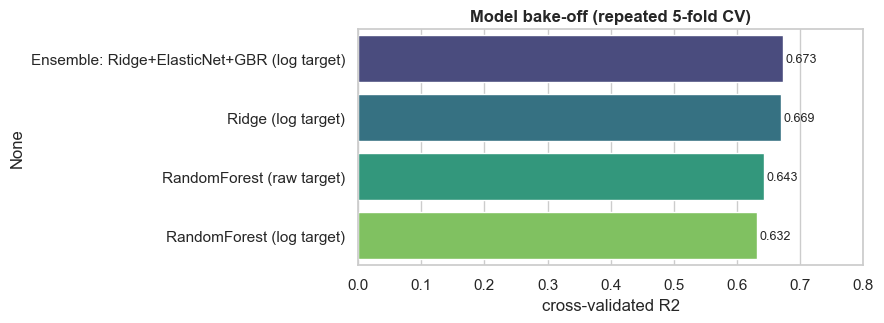

Best model: Ensemble: Ridge+ElasticNet+GBR (log target)  (CV R2 = 0.673)


,cv_r2_mean,cv_r2_std
Ensemble: Ridge+ElasticNet+GBR (log target),0.673,0.041
Ridge (log target),0.669,0.045
RandomForest (raw target),0.643,0.046
RandomForest (log target),0.632,0.050


In [37]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import GradientBoostingRegressor, VotingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet, Ridge
from sklearn.model_selection import RepeatedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# leakage = anything derived from price
LEAKAGE = ["price_per_sqft", "log_price", "price_segment"]
Xm = (df.select_dtypes("number")
        .drop(columns=["price"] + LEAKAGE, errors="ignore")
        .replace([np.inf, -np.inf], np.nan))
ym = df["price"].astype(float)


def _linear(est):
    return Pipeline([("impute", SimpleImputer(strategy="median")),
                     ("scale", StandardScaler()),
                     ("model", est)])


_gbr = Pipeline([("impute", SimpleImputer(strategy="median")),
                 ("model", GradientBoostingRegressor(
                     n_estimators=600, learning_rate=0.02, max_depth=3,
                     subsample=0.8, random_state=42))])
_ensemble = VotingRegressor(
    estimators=[("ridge", _linear(Ridge(alpha=10.0))),
                ("elastic", _linear(ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=20000))),
                ("gbr", _gbr)],
    weights=[2, 2, 1])


def _logwrap(est):
    return TransformedTargetRegressor(regressor=est, func=np.log1p, inverse_func=np.expm1)


candidates = {
    "RandomForest (raw target)": RandomForestRegressor(
        n_estimators=600, random_state=42, n_jobs=-1),
    "RandomForest (log target)": _logwrap(RandomForestRegressor(
        n_estimators=600, random_state=42, n_jobs=-1)),
    "Ridge (log target)": _logwrap(_linear(Ridge(alpha=10.0))),
    "Ensemble: Ridge+ElasticNet+GBR (log target)": _logwrap(_ensemble),
}

_cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=42)
bakeoff = (pd.DataFrame(
    {"cv_r2_mean": {name: cross_val_score(m, Xm, ym, cv=_cv, scoring="r2").mean()
                    for name, m in candidates.items()}})
    .assign(cv_r2_std=lambda d: [cross_val_score(candidates[n], Xm, ym, cv=_cv,
            scoring="r2").std() for n in d.index])
    .sort_values("cv_r2_mean", ascending=False))
best_model_r2 = bakeoff["cv_r2_mean"].max()

fig, ax = plt.subplots(figsize=(9, 3.4))
sns.barplot(x=bakeoff["cv_r2_mean"], y=bakeoff.index, palette=CONFIG.palette, ax=ax)
for y_, v in enumerate(bakeoff["cv_r2_mean"]):
    ax.text(v + 0.004, y_, f"{v:.3f}", va="center", fontsize=9)
ax.set_xlabel("cross-validated R2"); ax.set_xlim(0, max(0.8, best_model_r2 + 0.08))
ax.set_title("Model bake-off (repeated 5-fold CV)")
plt.tight_layout(); save_fig(fig, "20_model_bakeoff"); plt.show()

print(f"Best model: {bakeoff.index[0]}  (CV R2 = {best_model_r2:.3f})")
bakeoff.round(3)

## 14. PCA — is there latent structure in the feature space?

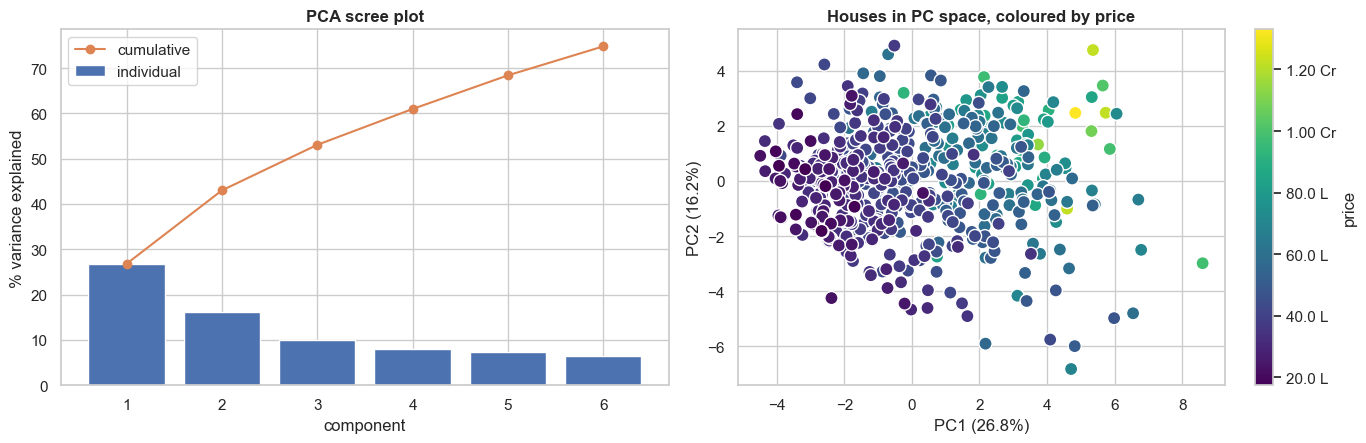

In [38]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

Xs = StandardScaler().fit_transform(X)
n_comp = min(len(feat_cols), len(df) - 1, 6)
pca = PCA(n_components=n_comp, random_state=42).fit(Xs)
scores = pca.transform(Xs)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))

axes[0].bar(range(1, n_comp + 1), pca.explained_variance_ratio_ * 100,
            color=CONFIG.accent, label="individual")
axes[0].plot(range(1, n_comp + 1), np.cumsum(pca.explained_variance_ratio_) * 100,
             marker="o", color=CONFIG.accent_2, label="cumulative")
axes[0].set_xlabel("component"); axes[0].set_ylabel("% variance explained")
axes[0].set_title("PCA scree plot"); axes[0].legend()

sc = axes[1].scatter(scores[:, 0], scores[:, 1], c=df["price"], cmap="viridis", s=90,
                     edgecolor="white")
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
axes[1].set_title("Houses in PC space, coloured by price")
plt.colorbar(sc, ax=axes[1], format=mticker.FuncFormatter(inr), label="price")

plt.tight_layout(); save_fig(fig, "19_pca"); plt.show()

## 15. Key findings & export

In [39]:
strongest = target_corr["pearson_r"].abs().idxmax()
print("=" * 68)
print("EDA SUMMARY".center(68))
print("=" * 68)
print(f"Rows / columns          : {df.shape[0]:,} / {df.shape[1]}")
print(f"Price range             : {inr(df['price'].min())} - {inr(df['price'].max())}")
print(f"Median price            : {inr(df['price'].median())}")
print(f"Median price per sqft   : {df['price_per_sqft'].median():,.1f}")
print(f"Price skewness          : {df['price'].skew():.2f} "
      f"({'right-skewed - consider log target' if df['price'].skew() > 0.5 else 'roughly symmetric'})")
print(f"Strongest correlate     : {strongest} (r = {target_corr.loc[strongest, 'pearson_r']:.2f})")
print(f"Top RF driver           : {imp.index[0]} ({imp['rf_importance'].iloc[0]:.1%})")
print(f"Best model (CV R2)      : {bakeoff.index[0]} ({best_model_r2:.3f})")
print(f"Price outliers (IQR)    : {int(ot.loc['price', 'n_outliers'])}")
print(f"Missing values          : {int(df.isna().sum().sum())}")
print("=" * 68)

                            EDA SUMMARY                             
Rows / columns          : 545 / 32
Price range             : 17.5 L - 1.33 Cr
Median price            : 43.4 L
Median price per sqft   : 952.4
Price skewness          : 1.21 (right-skewed - consider log target)
Strongest correlate     : amenity_score (r = 0.55)
Top RF driver           : area_x_ac (15.8%)
Best model (CV R2)      : Ensemble: Ridge+ElasticNet+GBR (log target) (0.673)
Price outliers (IQR)    : 15
Missing values          : 0


In [40]:
df.to_csv(CONFIG.processed_path, index=False)
print(f"Processed dataset -> {CONFIG.processed_path}")
print(f"Figures saved     -> {CONFIG.fig_dir} ({len(list(CONFIG.fig_dir.glob('*.png')))} files)")

Processed dataset -> /Users/mapmac/Desktop/D/FAST/SEM-4-Autumn-2026/MLOPs/Assignments/Assignment-1/MLOPs-Assignment-23L8072/data/Housing_processed.csv
Figures saved     -> /Users/mapmac/Desktop/D/FAST/SEM-4-Autumn-2026/MLOPs/Assignments/Assignment-1/MLOPs-Assignment-23L8072/outputs/figures (20 files)
